<a href="https://colab.research.google.com/github/HawwaSherin/Sign-Language-CNN-M6-Assignment/blob/main/CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Title: Sign Language Recognition using CNN**

This project focuses on building a deep learning model to recognize hand gestures representing letters in sign language. the dataset used is Sign Language MNIST dataset. It consists of graysacale images representing 24 alphabet classes (A-Y, excluding J and Z)
Main objectives:


*   build a baseline CNN
*   improve it with enhanced architectures

*   Compare and Evaluate them







**DATA LOADING**

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

# Loading dataset
train = pd.read_csv('sign_mnist_train.csv')
test = pd.read_csv('sign_mnist_test.csv')

# Separate features and labels
X_train = train.drop('label', axis=1)
y_train = train['label']

X_test = test.drop('label', axis=1)
y_test = test['label']

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (27455, 784)
Test shape: (7172, 784)


**PREPROCESSING**

In [2]:
# Reshape into image format
X_train = X_train.values.reshape(-1, 28, 28, 1)
X_test = X_test.values.reshape(-1, 28, 28, 1)

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

y_train = y_train - 1
y_val = y_val - 1

# One-hot encoding
from tensorflow.keras.utils import to_categorical
import numpy as np

num_classes = len(np.unique(y_train))

y_train = to_categorical(y_train, num_classes=num_classes)
y_val = to_categorical(y_val, num_classes=num_classes)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (21964, 28, 28, 1)
Validation: (5491, 28, 28, 1)




*   Reshaped images to 28x28 pixel format
*   Normalization is used to imrpove model performance
*   Validation set helps monitor overfitting






**BASELINE CNN MODEL**

In [3]:
# Importing required layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Get no:of output classes from labels
num_classes = y_train.shape[1]

# Inizializing the model
baseline_model = Sequential()

# First Convolution and Pooling
baseline_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
baseline_model.add(MaxPooling2D((2,2)))

# Second Convolution and Pooling
baseline_model.add(Conv2D(64, (3,3), activation='relu'))
baseline_model.add(MaxPooling2D((2,2)))

# Flatten feature maps
baseline_model.add(Flatten())

# Fully connected layer
baseline_model.add(Dense(128, activation='relu'))

# Output layer
baseline_model.add(Dense(num_classes, activation='softmax'))

# Compile model
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)




1.   Built a basic CNN Model with Conv2D and MaxPooling layers
2.   Used cnvolution and pooling layers
3.  Extracted image features
4.   Used coftmax for multi-class classification






**TRAINING BASELINE MODEL**

In [4]:
history_base = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.5960 - loss: 1.3786 - val_accuracy: 0.8882 - val_loss: 0.3845
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.9537 - loss: 0.1889 - val_accuracy: 0.9907 - val_loss: 0.0655
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.9959 - loss: 0.0371 - val_accuracy: 0.9991 - val_loss: 0.0177
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.9996 - loss: 0.0107 - val_accuracy: 0.9998 - val_loss: 0.0062
Epoch 5/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.9999 - loss: 0.0048 - val_accuracy: 0.9998 - val_loss: 0.0037
Epoch 6/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9999 - loss: 0.0028 - val_accuracy: 0.9976 - val_loss: 0.0093
Epoch 7/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.9946 - loss: 0.0205 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 8/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 1.0000 - loss: 8.7061e-0

**ENHANCED MODEL- AlexNet-Style Model**

In [5]:
from tensorflow.keras.layers import Dropout

# Intialize enhanced model
alex_model = Sequential()

# Convolution block 1
alex_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
alex_model.add(MaxPooling2D((2,2)))

# Convolution block 2
alex_model.add(Conv2D(64, (3,3), activation='relu'))
alex_model.add(MaxPooling2D((2,2)))

# Convolution block 3 (deeper feature extraction)
alex_model.add(Conv2D(128, (3,3), activation='relu'))
alex_model.add(MaxPooling2D((2,2)))

# Flattening
alex_model.add(Flatten())

# dense layer
alex_model.add(Dense(128, activation='relu'))

# Dropout
alex_model.add(Dropout(0.5))

# Output layer
alex_model.add(Dense(num_classes, activation='softmax'))  # ✅ FIX

# Compile
alex_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



*   Built deeper CNN (AlexNet-Style)
*   Added extra convolution layer
*   Dropout reduces overfitting
*   Improved feature extraction



**TRAINING ENHANCED MODEL**

In [6]:
history_alex = alex_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.2909 - loss: 2.2700 - val_accuracy: 0.6844 - val_loss: 1.0635
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.6721 - loss: 0.9621 - val_accuracy: 0.8430 - val_loss: 0.5320
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.8085 - loss: 0.5581 - val_accuracy: 0.9060 - val_loss: 0.2861
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.8810 - loss: 0.3443 - val_accuracy: 0.9628 - val_loss: 0.1275
Epoch 5/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9252 - loss: 0.2222 - val_accuracy: 0.9825 - val_loss: 0.0831
Epoch 6/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.9542 - loss: 0.1432 - val_accuracy: 0.9978 - val_loss: 0.0311
Epoch 7/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.9665 - loss: 0.1063 - val_accuracy: 0.9964 - val_loss: 0.0232
Epoch 8/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9778 - loss: 0.0756 - 

**RESULTS AND EVALUATION**

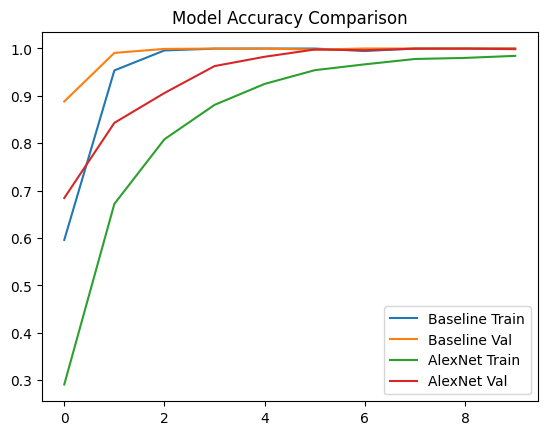

In [7]:
import matplotlib.pyplot as plt

# Plotting accuracy comparison
plt.plot(history_base.history['accuracy'], label='Baseline Train')
plt.plot(history_base.history['val_accuracy'], label='Baseline Val')

plt.plot(history_alex.history['accuracy'], label='AlexNet Train')
plt.plot(history_alex.history['val_accuracy'], label='AlexNet Val')

plt.legend()
plt.title("Model Accuracy Comparison")
plt.show()

*  Compared training and validation accuracy
*  Enhanced model performed better
*  Visulised performance difference

**CONFUSION MATRIX**

172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


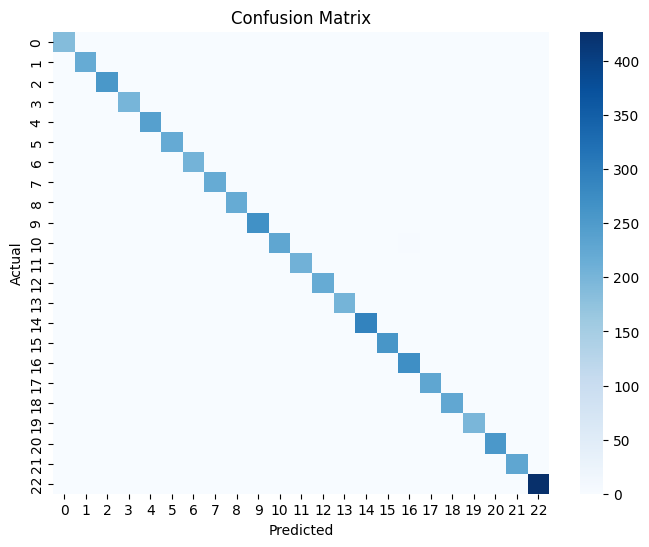

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Predictions
y_pred = alex_model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)

# Converting tru labels back
y_true = np.argmax(y_val, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

*  Evaluated Model predictions
*  Compared actual vs predicted labels
*  Identified classification performance

**CLASSIFICATION REPORT**

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       188
           1       1.00      1.00      1.00       220
           2       1.00      1.00      1.00       256
           3       1.00      1.00      1.00       202
           4       1.00      1.00      1.00       242
           5       1.00      1.00      1.00       221
           6       1.00      1.00      1.00       205
           7       1.00      1.00      1.00       219
           9       1.00      1.00      1.00       219
          10       1.00      1.00      1.00       268
          11       1.00      0.99      1.00       232
          12       1.00      1.00      1.00       209
          13       1.00      1.00      1.00       219
          14       1.00      1.00      1.00       202
          15       1.00      1.00      1.00       291
          16       1.00      1.00      1.00       261
          17       0.99      1.00      0.99       271
          18       1.00    